## Customer Insurance Purchase Prediction

**Business Goal:**

The Goal of this project is to develop a machine learning model that predicts whether a customer will purchase insurance based on two key attributes:

-Age

-Estimated Salary

The Objective is to analyze customer data while excluding sensitive information such as password or account numbers.Using historical customer data,the system aims to identify patterns that influence insurance purchasing behaviour.

By building predictive models,the company can:

-Identify potential customers who are likely to buy insurance

-Improve targeted marketing strategies

-Increase overall insurance policy convesions

**Importing all the required libraries**

In [151]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,recall_score,precision_score,roc_curve,auc
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Load the dataset**

In [152]:
data=pd.read_csv('customer_data.csv')

In [153]:
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [154]:
data[13:20]

,Age,EstimatedSalary,Purchased
13,32,18000,0
14,18,82000,0
15,29,80000,0
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1


In [155]:
data.shape

(400, 3)

## Data Preprocessing

The dataset contains customer demographic information including:

- Age
- Estimated Salary
- Purchased (Target variable)



**Data Preparation & Feature Scaling**

The following preprocessing steps are performed:

1. Selected relevant features: Age and EstimatedSalary
2. Separated features (X) and target variable (y)
3. Checking class distribution
4. Split the dataset into training and testing sets
5. Applied feature scaling using StandardScaler


In [156]:
x=data[['Age','EstimatedSalary']]
y=data['Purchased']

In [157]:
print("CLass Distribution:")
print(y.value_counts())

CLass Distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


**Train-test Split**

In [158]:
x_train, x_test,y_train,y_test=train_test_split(
    x,y ,test_size =0.2, random_state=42,stratify=y)

In [159]:
x_train

,Age,EstimatedSalary
65,24,58000
179,31,34000
109,38,80000
379,58,23000
325,41,60000
...,...,...
4,19,76000
18,46,28000
314,39,79000
170,21,88000


In [160]:
y_train

65     0
179    0
109    0
379    1
325    0
      ..
4      0
18     1
314    0
170    0
106    0
Name: Purchased, Length: 320, dtype: int64

In [161]:
scalar=StandardScaler()
x_train_scaled= scalar.fit_transform(x_train)
x_test_scaled =scalar.transform(x_test)

In [162]:
x_train_scaled

array([[-1.23446186, -0.367992  ],
       [-0.57764605, -1.05831408],
       [ 0.07916976,  0.26480323],
       [ 1.95578636, -1.3747117 ],
       [ 0.36066225, -0.31046516],
       [ 0.17300059,  0.17851297],
       [ 2.14344802,  0.35109349],
       [ 0.45449308, -0.48304568],
       [-0.01466107,  0.20727639],
       [-0.01466107,  0.17851297],
       [-0.85913854, -0.33922858],
       [-1.60978518, -1.3747117 ],
       [-1.23446186,  0.52367401],
       [-0.85913854, -0.77067988],
       [ 0.8298164 , -0.85697014],
       [ 1.01747806, -1.20213118],
       [ 0.17300059,  1.01265215],
       [-0.48381522,  1.41534003],
       [-0.29615356,  1.18523267],
       [ 0.17300059,  0.00593246],
       [ 1.11130889, -0.91449698],
       [-0.48381522, -1.5185288 ],
       [-1.79744684, -0.77067988],
       [ 0.07916976,  1.21399609],
       [-0.01466107,  1.90431817],
       [-0.20232273, -1.3747117 ],
       [-1.51595435, -0.0803578 ],
       [-0.20232273,  0.75378137],
       [ 0.92364723,

In [163]:
x_test_scaled

array([[ 1.01747806,  1.38657661],
       [-1.0468002 , -1.60481906],
       [-0.20232273, -1.46100196],
       [ 0.07916976,  1.18523267],
       [-1.60978518,  0.32233007],
       [ 1.58046304, -0.02283096],
       [ 0.26683142,  0.12098613],
       [ 2.14344802,  0.89759847],
       [ 2.04961719,  0.35109349],
       [-0.1084919 , -1.0870775 ],
       [ 0.26683142, -0.39675542],
       [ 0.92364723,  0.98388873],
       [ 0.92364723, -1.31718486],
       [ 0.73598557,  0.23603981],
       [-0.85913854,  1.50163029],
       [-0.20232273, -0.59809936],
       [-0.57764605,  0.14974955],
       [ 0.8298164 , -1.40347512],
       [ 0.36066225, -0.54057252],
       [ 1.7681247 ,  1.78926449],
       [-0.95296937,  0.55243743],
       [ 0.36066225,  0.46614717],
       [-0.20232273, -0.91449698],
       [ 0.64215474,  1.96184501],
       [-0.67147688,  0.26480323],
       [ 0.36066225,  0.03469588],
       [ 0.26683142,  1.04141557],
       [ 0.73598557, -1.40347512],
       [-1.0468002 ,

## Model Development

The following classification algorithms are implemented to predict whether a customer will purchase insurance:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest (Ensemble Learning)

Each model was trained using the scaled training dataset and evaluated using the test dataset.

## Model Evaluation

To evaluate the performance of each algorithm, the following metrics are used:

• Accuracy
• Precision
• Recall
• F1 Score
• Cross Validation Score


**Training and Evaluation**

**Logistic Regression**

In [164]:
log_model=LogisticRegression(class_weight='balanced',max_iter=500)
log_model.fit(x_train_scaled,y_train)
y_pred_log =log_model.predict(x_test_scaled)
print("Logistic Regression")
print("Accuracy:",accuracy_score(y_test,y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82        51
           1       0.68      0.79      0.73        29

    accuracy                           0.79        80
   macro avg       0.77      0.79      0.78        80
weighted avg       0.80      0.79      0.79        80



In [165]:
cv_scores_log= cross_val_score (log_model, x_train_scaled,y_train, cv=5,scoring='f1')
print("\n Logistic Cross-validation F1 scores :", cv_scores_log)
print("Logistic Mean CV F1:", cv_scores_log.mean())


 Logistic Cross-validation F1 scores : [0.85714286 0.70833333 0.85106383 0.78431373 0.82352941]
Logistic Mean CV F1: 0.8048766315036653


**KNeighbors Classifier**

In [166]:
knn_model=KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train_scaled,y_train)
y_pred_knn =knn_model.predict(x_test_scaled)
print("KNN")
print("Accuracy:",accuracy_score(y_test,y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.9125

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        51
           1       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



In [167]:
cv_scores_knn= cross_val_score (knn_model, x_train_scaled,y_train, cv=5,scoring='f1')
print("\n KNN Cross-validation scores F1:", cv_scores_knn)
print(" KNN Mean CV F1:", cv_scores_knn.mean())


 KNN Cross-validation scores F1: [0.93333333 0.79166667 0.93333333 0.875      0.84      ]
 KNN Mean CV F1: 0.8746666666666666


**Support Vector Classifier**

In [168]:
svm_model =SVC(kernel='rbf',C=10,class_weight='balanced')
svm_model.fit(x_train_scaled,y_train)
y_pred_svm =svm_model.predict(x_test_scaled)
print("SVM")
print("Accuracy:",accuracy_score(y_test,y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.9125

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        51
           1       0.84      0.93      0.89        29

    accuracy                           0.91        80
   macro avg       0.90      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



In [169]:
cv_scores_svm= cross_val_score (svm_model, x_train_scaled,y_train, cv=5,scoring='f1')
print("\n SVM Cross-validation F1 scores :", cv_scores_svm)
print(" SVM Mean CV F1:", cv_scores_svm.mean())


 SVM Cross-validation F1 scores : [0.93333333 0.82352941 0.95652174 0.85714286 0.84615385]
 SVM Mean CV F1: 0.8833362375050354


**Decision Tree Classifier**

In [170]:
dt_model =DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42)
dt_model.fit(x_train_scaled,y_train)
y_pred_dt=dt_model.predict(x_test_scaled)
print("Decision Tree")
print("Accuracy:",accuracy_score(y_test,y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.88        51
           1       0.76      0.86      0.81        29

    accuracy                           0.85        80
   macro avg       0.84      0.85      0.84        80
weighted avg       0.86      0.85      0.85        80



In [171]:
cv_scores_dt= cross_val_score (dt_model, x_train_scaled,y_train, cv=5,scoring='f1')
print("\n Decision Tree Cross-validation  F1 scores :", cv_scores_dt)
print("Decision Tree Mean CV F1:", cv_scores_dt.mean())


 Decision Tree Cross-validation  F1 scores : [0.9047619  0.77272727 0.95454545 0.85106383 0.80851064]
Decision Tree Mean CV F1: 0.8583218200239477


**Random Forest Classifier**

In [172]:
rf_model =RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf =rf_model.predict(x_test_scaled)
print("Random Forest")
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



In [173]:
cv_scores_rf= cross_val_score (rf_model, x_train_scaled,y_train, cv=5,scoring='f1')
print("\n Random Forest Cross-validation F1 scores :", cv_scores_rf)
print("Random Forest Mean CV F1:", cv_scores_rf.mean())


 Random Forest Cross-validation F1 scores : [0.9047619  0.72727273 0.95454545 0.83333333 0.81632653]
Random Forest Mean CV F1: 0.847247990105133


## Hyperparameter Tuning

Hyperparameter tuning is used to improve the performance of machine learning models by selecting the best combination of parameters. In this project, **GridSearchCV** is used to test different parameter values and choose the model configuration that gives the highest accuracy and better generalization.

**Hyperparameter Tuning of Logistic Regression**

In [174]:
param_log = {
    'C': [ 0.1, 1,10],
    'penalty': [ 'l2']
}
grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced',max_iter=500),
    param_log,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_log.fit(x_train_scaled, y_train)
print("\nBest Parameters:", grid_log.best_params_)
print("Best Cross-Validation Score:", grid_log.best_score_)
best_log=grid_log.best_estimator_
y_pred_log=best_log.predict(x_test_scaled)
print("Tuned Accuracy:",accuracy_score(y_test,y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Parameters: {'C': 10, 'penalty': 'l2'}
Best Cross-Validation Score: 0.8101922461216053
Tuned Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82        51
           1       0.68      0.79      0.73        29

    accuracy                           0.79        80
   macro avg       0.77      0.79      0.78        80
weighted avg       0.80      0.79      0.79        80



**Hyperparameter Tuning of KNeighbors Classifier**

In [175]:
param_knn = {
    'n_neighbors': [5,7,9],
    'metric': ['euclidean','manhattan']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(x_train_scaled, y_train)
print("\nBest Parameters:", grid_knn.best_params_)
print("Best Cross-Validation Score:", grid_knn.best_score_)
best_knn=grid_knn.best_estimator_
y_pred_knn=best_knn.predict(x_test_scaled)
print("Tuned Accuracy:",accuracy_score(y_test,y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best Cross-Validation Score: 0.879304347826087
Tuned Accuracy: 0.9125

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        51
           1       0.87      0.90      0.88        29

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



**Hyperparameter Tuning of Support Vector Classifier**

In [176]:
param_svm = {
    'C': [ 1,10],
    'kernel': ['rbf'],
    'gamma': ['scale']
}
grid_svm = GridSearchCV(
    SVC(class_weight='balanced',probability=True),
    param_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(x_train_scaled, y_train)
print("\nBest Parameters:", grid_svm.best_params_)
print("Best Cross-Validation Score:", grid_svm.best_score_)
best_svm=grid_svm.best_estimator_
y_predsvm=best_svm.predict(x_test_scaled)
print("Tuned Accuracy:",accuracy_score(y_test,y_predsvm))
print("\nClassification Report:\n", classification_report(y_test, y_predsvm))

Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8945522038602676
Tuned Accuracy: 0.9125

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93        51
           1       0.84      0.93      0.89        29

    accuracy                           0.91        80
   macro avg       0.90      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



**Hyperparameter Tuning of DecisionTree Classifier**

In [177]:
param_dt = {
    'max_depth':[None,5,10],
    'min_samples_split':[2,5]
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    param_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(x_train_scaled, y_train)
print("\nBest Parameters:", grid_dt.best_params_)
print("Best Cross-Validation Score:", grid_dt.best_score_)
best_dt=grid_dt.best_estimator_
y_pred_dt=best_dt.predict(x_test_scaled)
print("Tuned Accuracy:",accuracy_score(y_test,y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best Cross-Validation Score: 0.851518682263363
Tuned Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.88        51
           1       0.76      0.86      0.81        29

    accuracy                           0.85        80
   macro avg       0.84      0.85      0.84        80
weighted avg       0.86      0.85      0.85        80



**Hyperparameter Tuning of Random Forest Classifier**

In [178]:
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[None,5,10],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',random_state=42),
    param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(x_train_scaled, y_train)
print("\nBest Parameters:", grid_rf.best_params_)
print("Best Cross-Validation Score:", grid_rf.best_score_)
best_rf=grid_rf.best_estimator_
y_pred_rf=best_rf.predict(x_test_scaled)
print("Tuned Accuracy:",accuracy_score(y_test,y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters: {'max_depth': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.8760338680926918
Tuned Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



## Model Comparison

**Comparative Performance Analysis**

Below is the performance metrices across all models.
The models are evaluated using Accuracy,Precision,Recall,F1-Score.

In [179]:
results=pd.DataFrame({
    'Model':['Logistic Regression','KNN','Decision Tree','SVM','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,best_log.predict(x_test_scaled)),
        accuracy_score(y_test,best_knn.predict(x_test_scaled)),
        accuracy_score(y_test,best_svm.predict(x_test_scaled)),
        accuracy_score(y_test,best_dt.predict(x_test_scaled)),
        accuracy_score(y_test,best_rf.predict(x_test_scaled)),
    ],
    'Precision':[
        precision_score(y_test,best_log.predict(x_test_scaled)),
        precision_score(y_test,best_knn.predict(x_test_scaled)),
        precision_score(y_test,best_svm.predict(x_test_scaled)),
        precision_score(y_test,best_dt.predict(x_test_scaled)),
        precision_score(y_test,best_rf.predict(x_test_scaled)),
    ],
    'Recall':[
        recall_score(y_test,best_log.predict(x_test_scaled)),
        recall_score(y_test,best_knn.predict(x_test_scaled)),
        recall_score(y_test,best_svm.predict(x_test_scaled)),
        recall_score(y_test,best_dt.predict(x_test_scaled)),
        recall_score(y_test,best_rf.predict(x_test_scaled)),
    ],
    'F1 Score':[
        f1_score(y_test,best_log.predict(x_test_scaled)),
        f1_score(y_test,best_knn.predict(x_test_scaled)),
        f1_score(y_test,best_svm.predict(x_test_scaled)),
        f1_score(y_test,best_dt.predict(x_test_scaled)),
        f1_score(y_test,best_rf.predict(x_test_scaled))
    ]
})
results
        

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7875,0.676471,0.793103,0.730159
1,KNN,0.9125,0.866667,0.896552,0.881356
2,Decision Tree,0.9125,0.843750,0.931034,0.885246
3,SVM,0.8500,0.757576,0.862069,0.806452
4,Random Forest,0.9000,0.838710,0.896552,0.866667


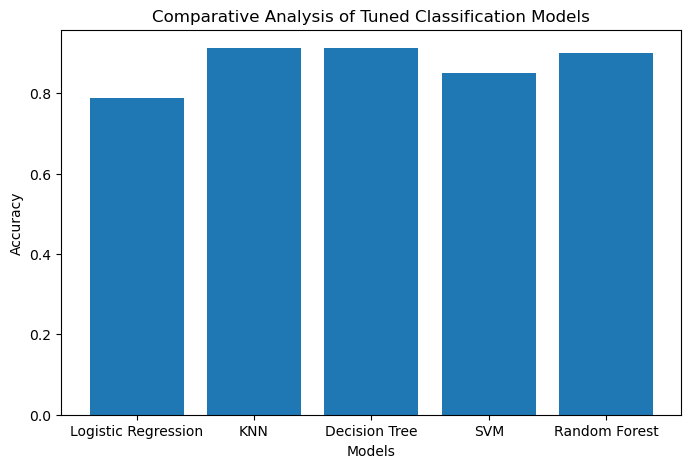

In [180]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'],results['Accuracy'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparative Analysis of Tuned Classification Models")
plt.show()


**Best Model Selection**

In [181]:
best_model=results.loc[results['Accuracy'].idxmax()]
print("Best Model:",best_model['Model'])
models={
    "logistgic":log_model,
    "KNN":knn_model,
    "SVM":svm_model,
    "Decision Tree":dt_model,
    "Random Forest":rf_model
}
best_trained_model=models[best_model['Model']]


Best Model: KNN


**ROC Curve**

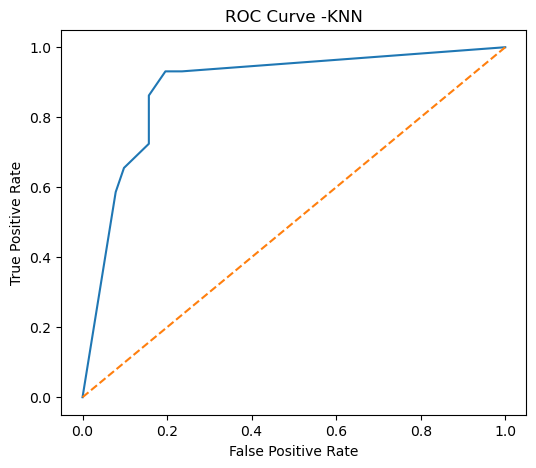

AUC: 0.8857336037863421


In [182]:
y_prob_knn= best_dt.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -KNN")
plt.show()

print("AUC:", roc_auc)

**Confusion Matrix**

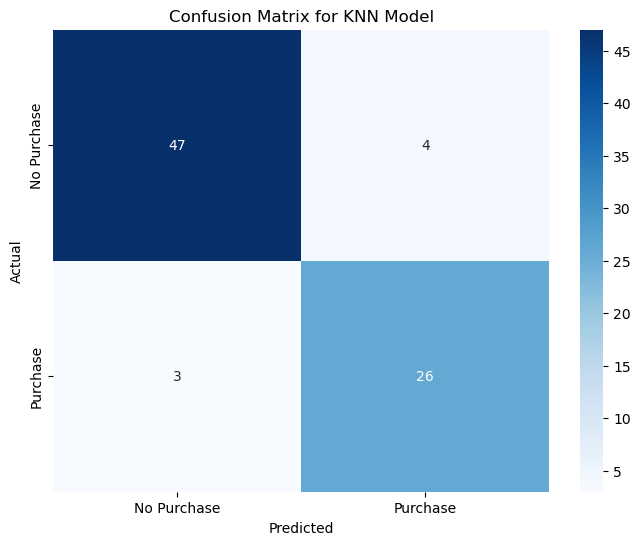

In [193]:
y_pred=best_trained_model.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No Purchase','Purchase'],
            yticklabels=['No Purchase','Purchase'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Model')
plt.show()


## Scenario Analysis


To understand how the trained model behaves under different real-world situations, two sets of scenarios were created.

The trained model predicts whether customers with different combinations of age and salary are likely to purchase insurance.

These predictions help analyze how demographic factors influence insurance purchasing behavior.

In [184]:
scenario1=pd.DataFrame(
    [[30,87000],
    [40,0],
    [40,100000],
    [50,0]],
    columns=['Age','EstimatedSalary']
)
scenario1_scaled=scalar.transform(scenario1)
predictions1=best_trained_model.predict(scenario1_scaled)

print("Scenario 1 Predictions:")
for i,pred in enumerate(predictions1):
    result="Will Purchase" if pred==1 else "Will Not Purchase"
    print(f"Customer{i+1}:{result}")


Scenario 1 Predictions:
Customer1:Will Not Purchase
Customer2:Will Not Purchase
Customer3:Will Purchase
Customer4:Will Purchase


**Graphical Analysis and Predictions For Scenario 1**

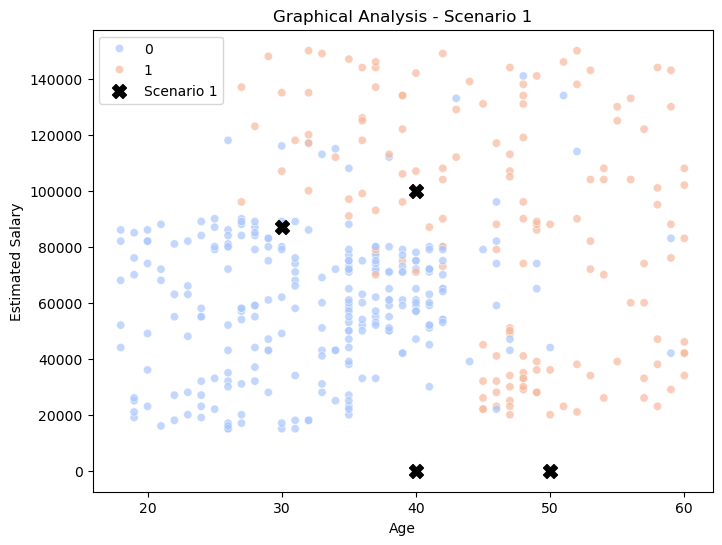

In [185]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=data,
    palette='coolwarm',
    alpha=0.7
)

plt.scatter([30,40,40,50],
            [87000,0,100000,0],
            color='black', marker='X', s=100, label='Scenario 1')


plt.title("Graphical Analysis - Scenario 1")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

In [186]:
scenario2=pd.DataFrame(
    [[18,0],
    [22,600000],
    [35,2500000],
    [60,100000000]],
    columns=['Age','EstimatedSalary']
)
scenario2_scaled=scalar.transform(scenario2)
predictions2=best_trained_model.predict(scenario2_scaled)

print("Scenario 2 Predictions:")
for i,pred in enumerate(predictions2):
   result="Will Purchase" if pred==1 else "Will Not Purchase"
   print(f"Customer{i+1}:{result}")

Scenario 2 Predictions:
Customer1:Will Not Purchase
Customer2:Will Purchase
Customer3:Will Purchase
Customer4:Will Purchase


**Graphical Analysis and Predictions For Scenario 2**

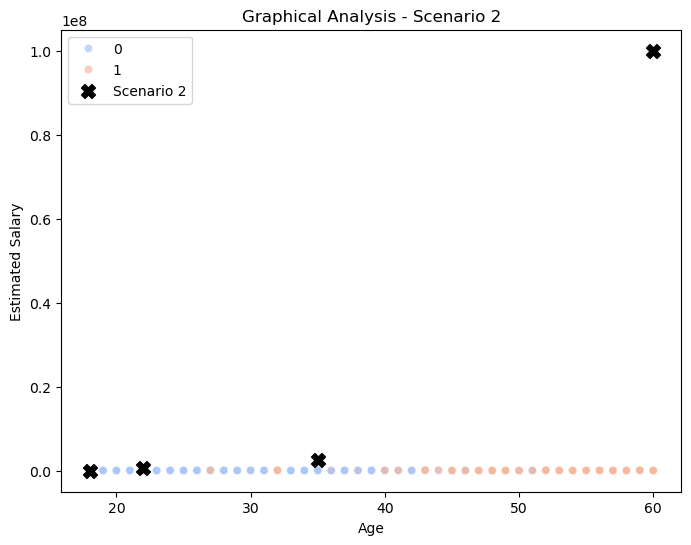

In [187]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=data,
    palette='coolwarm',
    alpha=0.7
)

plt.scatter([18,22,35,60],
            [0,600000,2500000,100000000],
            color='black', marker='X', s=100, label='Scenario 2')

plt.title("Graphical Analysis - Scenario 2")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

## Hypothesis and Assumptions

Testing the trained model on the following assumptions:

1.Yonger indivgiduals withg hgih salaries are more likely to purchase insurance.

2.Older individuals with higher salaries might be less inclined to purchase.

3.Salary has strongerimpact on purchasing behavior than age.

In [188]:
assumption1=pd.DataFrame(
    [[25,150000]],
    columns=['Age','EstimatedSalary']
)
assumption1_scaled=scalar.transform(assumption1)
predictions1=best_trained_model.predict(assumption1_scaled)

print(f"Prediction For Age 25 with 150K:{'Purchase' if predictions1[0]==1 else 'No Purchase'}")

Prediction For Age 25 with 150K:Purchase


In [189]:
assumption2=pd.DataFrame(
    [[55,40000]],
    columns=['Age','EstimatedSalary']
)
assumption2_scaled=scalar.transform(assumption2)
predictions2=best_trained_model.predict(assumption2_scaled)

print(f"Prediction For Age 55 with 40K:{'Purchase' if predictions2[0]==1 else 'No Purchase'}")


Prediction For Age 55 with 40K:Purchase


In [190]:
low_salary=pd.DataFrame(
    [[35,30000]],
    columns=['Age','EstimatedSalary']
)
high_salary=pd.DataFrame(
    [[35,150000]],
    columns=['Age','EstimatedSalary']
)
low_salary_scaled=scalar.transform(low_salary)
pred_low=best_trained_model.predict(low_salary_scaled)

high_salary_scaled=scalar.transform(high_salary)
pred_high=best_trained_model.predict(high_salary_scaled)

print("Low Salary Prediction:",
      "Purchase" if pred_low[0]==1 else "No Purchase")

print("High Salary Prediction:",
      "Purchase" if pred_high[0]==1 else "No Purchase")


Low Salary Prediction: No Purchase
High Salary Prediction: Purchase


## Lessons Learned

This study demonstrates how machine learning can be used to analyze customer behavior and make predictions based on historical data.

Key learnings include:

• The importance of proper data preprocessing and feature scaling.

• Different machine learning algorithms produce different performance results.

• Ensemble methods such as Random Forest often provide better generalization performance.

• Cross validation helps ensure that models do not overfit the training data.

## Real Life Applications

Case Study 1: Insurance Marketing

Insurance companies can use machine learning models to identify potential customers who are most likely to purchase insurance. This allows companies to target their marketing campaigns more effectively and increase sales.

Case Study 2: Banking Customer Analytics

Banks can use similar models to predict which customers are likely to buy financial products such as loans, credit cards, or investment plans. This helps financial institutions personalize their services and improve customer satisfaction.

## Conclusion

This project performed a comparative study of multiple classification algorithms to predict whether customers will purchase insurance based on their age and estimated salary.

Among all the algorithms tested, the model with the highest performance metrics was selected as the optimal model. The analysis demonstrates how machine learning can assist businesses in predicting customer behavior and making data-driven decisions.

By using predictive analytics, insurance companies can improve their marketing strategies, reduce costs, and increase customer acquisition.